In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from mplsoccer import Pitch, VerticalPitch

In [45]:
df = pd.read_csv("data/kmeanstutorial.csv")
df.head()

,Unnamed: 0,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,counterpress,dribble_outcome,dribble_overrun,duel_outcome,...,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_replacement,tactics,team,timestamp,type,under_pressure
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",France,00:00:00.000,Starting XI,NaN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Croatia,00:00:00.000,Starting XI,NaN
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,France,00:00:00.000,Half Start,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Croatia,00:00:00.000,Half Start,NaN
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Croatia,00:00:00.000,Half Start,NaN


In [46]:
df.columns

Index(['Unnamed: 0', 'ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'block_deflection', 'carry_end_location', 'clearance_aerial_won',
       'counterpress', 'dribble_outcome', 'dribble_overrun', 'duel_outcome',
       'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_penalty', 'foul_committed_type',
       'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part',
       'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position',
       'goalkeeper_technique', 'goalkeeper_type', 'id', 'index',
       'injury_stoppage_in_chain', 'interception_outcome', 'location',
       'match_id', 'minute', 'pass_aerial_won', 'pass_angle',
       'pass_assisted_shot_id', 'pass_backheel', 'pass_body_part',
       'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location',
       'pass_goal_assist', 'pass_height', 'pass_length', 'pass_outcome',
       'pass_recipient', 'pass_shot_assist', 'pass_switch', 'pa

In [47]:
df = df[['team', 'type', 'pass_end_location', 'location']]
df.head()

,team,type,pass_end_location,location
0,France,Starting XI,NaN,NaN
1,Croatia,Starting XI,NaN,NaN
2,France,Half Start,NaN,NaN
3,Croatia,Half Start,NaN,NaN
4,Croatia,Half Start,NaN,NaN


In [48]:
df = df[(df['team'] == 'France') & (df['type'] == 'Pass')].reset_index(drop=True)
df.head()

,team,type,pass_end_location,location
0,France,Pass,"[48.0, 60.0]","[48.0, 50.0]"
1,France,Pass,"[46.0, 61.0]","[49.0, 80.0]"
2,France,Pass,"[66.0, 69.0]","[65.0, 64.0]"
3,France,Pass,"[65.0, 79.0]","[63.0, 73.0]"
4,France,Pass,"[26.0, 69.0]","[58.0, 79.0]"


In [49]:
df[['x', 'y']] = df.location.str.strip('[]').str.split(',', expand=True).astype(float)
df[['end_X', 'end_Y']] = df.pass_end_location.str.strip('[]').str.split(',', expand=True).astype(float)
df.head()

,team,type,pass_end_location,location,x,y,end_X,end_Y
0,France,Pass,"[48.0, 60.0]","[48.0, 50.0]",48.0,50.0,48.0,60.0
1,France,Pass,"[46.0, 61.0]","[49.0, 80.0]",49.0,80.0,46.0,61.0
2,France,Pass,"[66.0, 69.0]","[65.0, 64.0]",65.0,64.0,66.0,69.0
3,France,Pass,"[65.0, 79.0]","[63.0, 73.0]",63.0,73.0,65.0,79.0
4,France,Pass,"[26.0, 69.0]","[58.0, 79.0]",58.0,79.0,26.0,69.0


In [50]:
df.drop(['location', 'pass_end_location'], axis=1, inplace=True)
df.head()

,team,type,x,y,end_X,end_Y
0,France,Pass,48.0,50.0,48.0,60.0
1,France,Pass,49.0,80.0,46.0,61.0
2,France,Pass,65.0,64.0,66.0,69.0
3,France,Pass,63.0,73.0,65.0,79.0
4,France,Pass,58.0,79.0,26.0,69.0


In [51]:
X = np.array(df[['x', 'y', 'end_X', 'end_Y']])
kmeans = KMeans(n_clusters=10, random_state=100).fit(X)
df['cluster'] = kmeans.predict(X)
df.head()

,team,type,x,y,end_X,end_Y,cluster
0,France,Pass,48.0,50.0,48.0,60.0,7
1,France,Pass,49.0,80.0,46.0,61.0,7
2,France,Pass,65.0,64.0,66.0,69.0,5
3,France,Pass,63.0,73.0,65.0,79.0,7
4,France,Pass,58.0,79.0,26.0,69.0,7


In [53]:
df.cluster.value_counts()

cluster
9    43
0    39
4    35
5    35
7    34
3    27
1    23
2    21
8    19
6    16
Name: count, dtype: int64

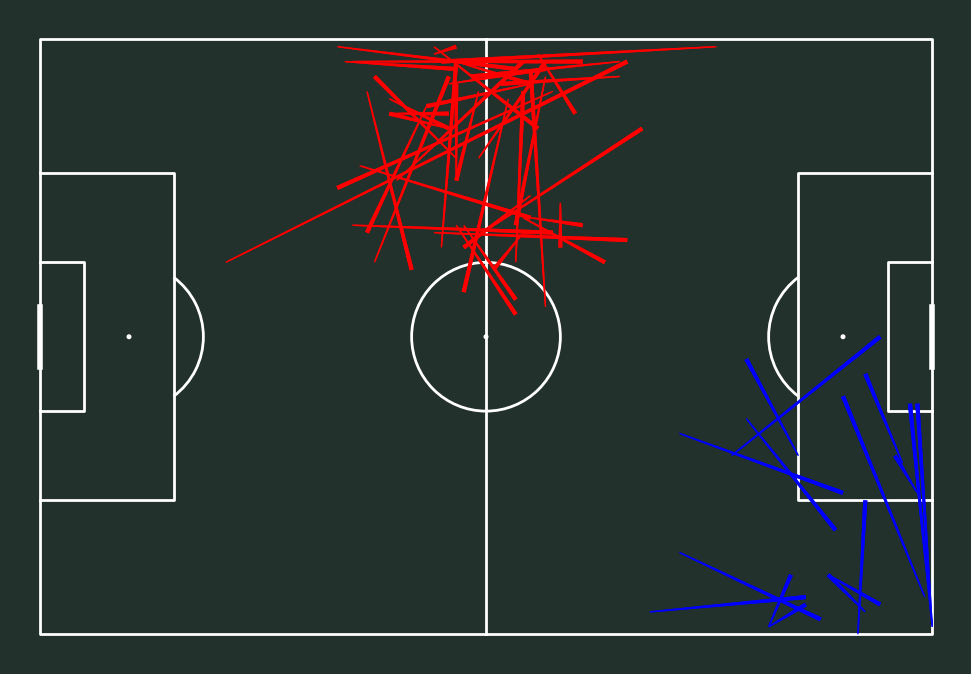

In [60]:
fig, ax = plt.subplots(figsize=(13, 8.5))
fig.set_facecolor('#22312b')
ax.patch.set_facecolor('#22312b')
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax, constrained_layout=True, tight_layout=False, figsize=(13, 8.5))

for i in range(len(df['cluster'])):
    if df['cluster'][i] == 9:
        pitch.lines(xstart=df['x'][i], ystart=df['y'][i], xend=df['end_X'][i], yend=df['end_Y'][i], ax=ax, color='red', lw=3, comet=True)
    elif df['cluster'][i] == 6:
        pitch.lines(xstart=df['x'][i], ystart=df['y'][i], xend=df['end_X'][i], yend=df['end_Y'][i], ax=ax, color='blue', comet=True, lw=3)
    #elif df['cluster'][i] == 4:
    #    pitch.lines(xstart=df['x'][i], ystart=df['y'][i], xend=df['end_X'][i], yend=df['end_Y'][i], ax=ax, color='green', lw=2, comet=True)